In [1]:
import torch
from env import FJSPTEnv
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from pathlib import Path
from greedy_policies import GreedyPolicy
from rl4co.envs import ENV_REGISTRY

ENV_REGISTRY["fjspt"] = FJSPTEnv

# Окружение для тестирования модели с помощью подготовленных датасетов
env = FJSPTEnv(
    generator_params={
      # датасеты с данными FJSP
      "proc_file_path": Path("../datasets/2_Ham/edata/orb7.fjs"),
      # датасет с временем транспортировки
      "trucks_file_path": Path("../datasets/2_Ham/trucks_data"),
      # индексация машин в разных датасетах разная (0/1)
      "ma_indexing": 1,
    },
)

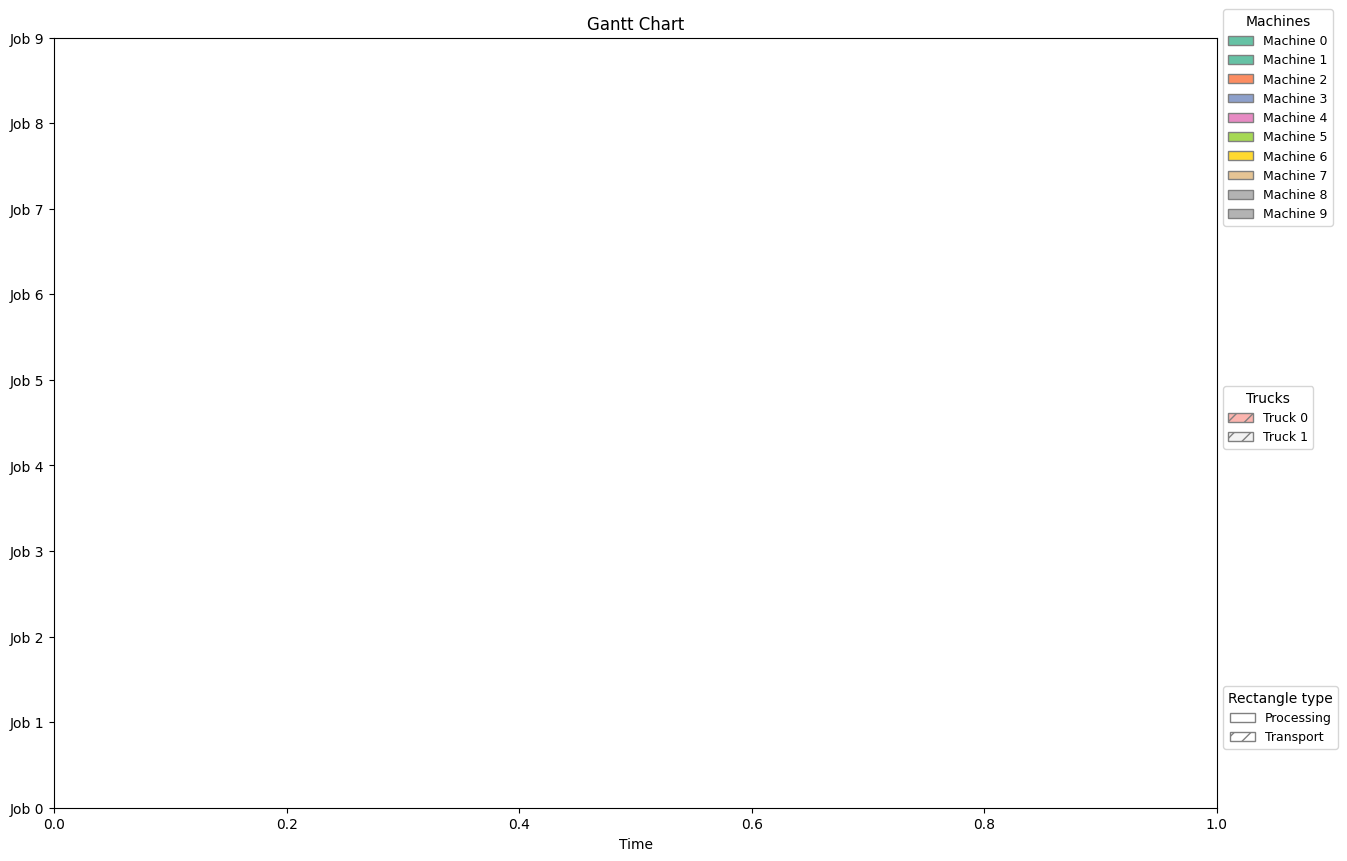

valid_machines_mask = tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]]])
valid_machines_mask = tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0.

In [2]:
device = torch.device("cpu")

policy = GreedyPolicy(policy_type="FIFO")
policy = policy.to(device)

policy.eval()
td = env.reset(batch_size=[1]).to(device)
fig = None
env.render(td.cpu(), 0)
plt.show()

while not td["done"].all():
    out = policy(td)
    td["action"] = out[0].argmax(dim=1)
    td = env.step(td)["next"]
    
    clear_output(wait=True)
    if fig is not None:
        plt.close(fig)
    fig = plt.figure()
    _, machine_schedule, trucks_schedule, ops_debug, machine_conflicts, truck_conflicts, job_conflicts = env.render(td.cpu(), 0)
    plt.show()
    
    time.sleep(1)

In [4]:
from validation import validate_solution
validate_solution(td, idx=0, verbose=True)

VALID SOLUTION


True

In [5]:
machine_schedule

defaultdict(list,
            {0: [(0, 6.0, 18.0),
              (3, 18.0, 54.0),
              (8, 72.0, 96.0),
              (12, 96.0, 114.0)],
             2: [(1, 70.0, 94.0), (5, 124.0, 154.0), (10, 94.0, 124.0)],
             4: [(4, 64.0, 76.0), (6, 24.0, 42.0), (11, 46.0, 52.0)],
             6: [(2, 170.0, 188.0), (7, 56.0, 62.0), (9, 24.0, 36.0)]})

In [6]:
trucks_schedule

defaultdict(list,
            {0: [(0, 0, 0.0, 6.0),
              (2, 2, 6.0, 24.0),
              (4, 0, 54.0, 70.0),
              (9, 3, 70.0, 82.0),
              (11, 1, 82.0, 98.0)],
             1: [(1, 1, 0.0, 6.0),
              (3, 3, 6.0, 24.0),
              (5, 4, 24.0, 46.0),
              (6, 2, 52.0, 56.0),
              (7, 1, 56.0, 64.0),
              (8, 2, 64.0, 72.0),
              (10, 4, 76.0, 88.0),
              (12, 0, 154.0, 170.0)]})

In [3]:
reward = td["machine_finish_times"].masked_fill(td["pad_mask"], -torch.inf).max(1).values
print(f"Cost: {reward}")

Cost: tensor([188.], device='cuda:0')


In [1]:
import torch
from env import FJSPTEnv
from pathlib import Path
import pandas as pd
from greedy_policies import GreedyPolicy
from rl4co.envs import ENV_REGISTRY

ENV_REGISTRY["fjspt"] = FJSPTEnv

datasets_params = [
    ("1_Deroussi_and_Norre", "../datasets/1_Deroussi_and_Norre/proc_data", 1),
    ("2_Ham_edata", "../datasets/2_Ham/edata", 1),
    ("2_Ham_rdata", "../datasets/2_Ham/rdata", 1),
    ("2_Ham_sdata", "../datasets/2_Ham/sdata", 1),
    ("2_Ham_vdata", "../datasets/2_Ham/vdata", 1),
    ("3_Homayouni_and_Fontes-Brandimarte", "../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data", 1),
    ("4_Homayouni_and_Fontes-Fattahi", "../datasets/4_Homayouni_and_Fontes-Fattahi/proc_data", 0),
    ("5_Dauzere", "../datasets/5_Dauzere/proc_data", 1),
]

results = {}
device = torch.device("cpu")
strategies = ["FIFO", "MOPNR", "SPT", "MWKR"]
policies = {
    s: GreedyPolicy(policy_type=s).to(device).eval()
    for s in strategies
}

for dataset_name, proc_path, ma_indexing in datasets_params:
    print("-" * 20)
    print(proc_path)
    path = Path(proc_path)
    rows = []
    
    for file in path.iterdir():
        if not file.is_file():
            continue
        print(file)
        row = {"file": str(file).split("/")[-1]}
            
        for strategy in strategies:
            print(strategy)
            policy = policies[strategy]
  
            # Окружение для тестирования модели с помощью подготовленных датасетов
            env = FJSPTEnv(
                generator_params={
                  # датасеты с данными FJSP
                  "proc_file_path": file,
                  # датасет с временем транспортировки
                  "trucks_file_path": Path(proc_path).parent / "trucks_data",
                  "ma_indexing": ma_indexing,
                },
            )
            
            td = env.reset(batch_size=[1]).to(device)
            
            while not td["done"].all():
                out = policy(td)
                td["action"] = out[0].argmax(dim=1)
                td = env.step(td)["next"]
                
            reward = td["machine_finish_times"].masked_fill(td["pad_mask"], -torch.inf).max(1).values
            row[strategy] = reward.item()
            
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("file")
    save_path = f"greedy_results/{dataset_name}.csv"
    df.to_csv(save_path, index=False)
    print(f"Saved to {save_path}")

--------------------
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt10.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt01.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt05.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt02.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt06.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt08.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt07.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt03.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt09.txt
FIFO
MOPNR
SPT
MWKR
../datasets/3_Homayouni_and_Fontes-Brandimarte/proc_data/mkt04.txt
FIFO
MOPNR
SPT
MWKR
Saved to greedy_results/3_Homayouni_and_Fontes-Brand